In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = next(
    p for p in (cwd, *cwd.parents)
    if (p / "rebound").is_dir() and (p / "src").is_dir()
)
sys.path.insert(0, str(repo_root))

import rebound
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def getSim(m=1.0, encounter=True):
    sim = rebound.Simulation()
    sim.add(m=1)
    sim.add(m=1e-6*m, a=1)
    if encounter: 
        planet = sim.particles[-1]
        asteroid = planet.copy()
        asteroid.x += 0.001
        o = asteroid.orbit(primary=planet)
        vesc = np.sqrt(2*(planet.m+asteroid.m)/o.d)
        asteroid.vy += 1.2*vesc
        sim.add(asteroid)
    else:
        sim.add(m=1e-6*m, a=1.5)
    sim.integrate(-np.pi)
    return sim

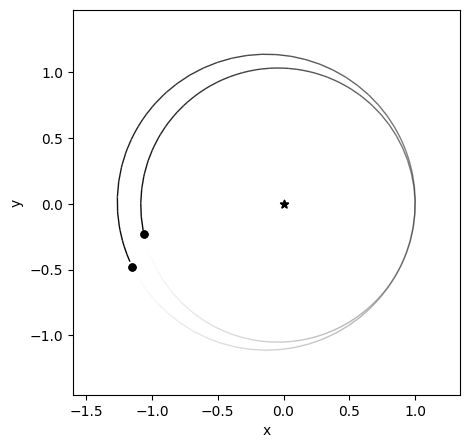

In [3]:
sim = getSim()
rebound.OrbitPlot(sim)

In [18]:
sim.particles[1].P

6.688979257361997

In [4]:
dts = np.logspace(-3,1,20)
Es = np.zeros(len(dts))
Es_hj = np.zeros(len(dts))
for i, dt in enumerate(dts):
    sim = getSim()
    sim.integrator = "whfast"
    sim.dt = dt
    E0 = sim.energy()
    sim.integrate(np.pi)
    E1 = sim.energy()
    Es[i] = np.abs((E0-E1)/E0)

    sim = getSim()
    sim.integrator = "whfast_hj"
    sim.dt = dt
    E0 = sim.energy()
    sim.integrate(np.pi)
    E1 = sim.energy()
    Es_hj[i] = np.abs((E0-E1)/E0)

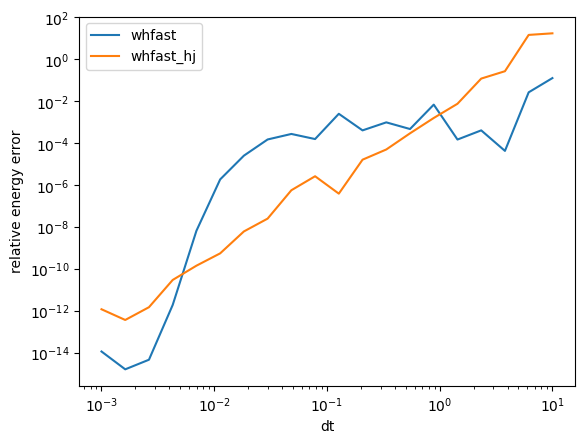

In [5]:
fig,ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
ax.plot(dts, Es, label="whfast")
ax.plot(dts, Es_hj, label="whfast_hj")
ax.set_xlabel("dt")
ax.set_ylabel("relative energy error")
ax.legend()
# ax.plot(dts, 1e-6*dts**2)

/Users/ziruiliu/Ray/school/2026_summer/Hanno/rebound/rebound/simulation.py:264: RuntimeWarning: Possible convergence issue. Timestep in Kepler solver is larger than one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


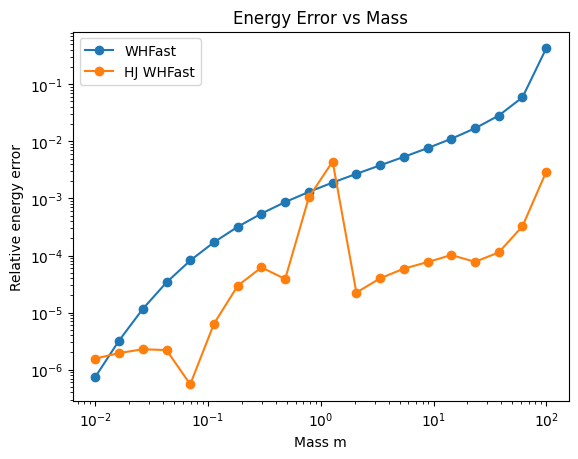

In [6]:
ms = np.logspace(-2,2,20)
Es = np.zeros(len(ms))
Es_HJ = np.zeros(len(ms))
for i, m in enumerate(ms):
    # print("m= ", m)
    
    # regular Jacobin run
    sim = getSim(m=m)
    sim.integrator = "whfast"
    sim.dt = 0.2
    E0 = sim.energy()
    sim.integrate(np.pi*2) 
    E1 = sim.energy()
    Es[i] = np.abs((E0-E1)/E0)


    # HJ Jacobin run
    sim = getSim(m=m)
    sim.integrator = "whfast_hj"
    sim.dt = 0.2
    E0 = sim.energy()
    sim.integrate(np.pi*2) 
    E1 = sim.energy()
    Es_HJ[i] = np.abs((E0-E1)/E0)


fig,ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
ax.plot(ms, Es, marker="o", label="WHFast")
ax.plot(ms, Es_HJ, marker="o", label="HJ WHFast")

ax.set_xlabel("Mass m")
ax.set_ylabel("Relative energy error")
ax.set_title("Energy Error vs Mass")

ax.legend()

# ax.grid(True, which="both")

# fig.savefig("energy_error_vs_mass.png", dpi=300, bbox_inches="tight")
plt.show()